# Edumetricas
Sistema unificado de avaliação estudantil

## 1-) Configurações

In [50]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'

DADOS_ESCOLA = '../../data/internal/'
DADOS_NACIONAL = '../../data/external/'

UF_ESCOLA = 'PB'
AULAS_BIMESTRE = 60
LIMITE_NOTA_APROVACAO = 7.0

DISCIPLINAS_ESCOLA = {
    'matematica':        'Matemática',
    'linguagens':        'Linguagens',
    'ciencias_natureza': 'Ciências da Natureza',
    'ciencias_humanas':  'Ciências Humanas'
}

ENEM_COLUNAS = {
    'NU_NOTA_MT': 'Matemática',
    'NU_NOTA_LC': 'Linguagens',
    'NU_NOTA_CN': 'Ciências da Natureza',
    'NU_NOTA_CH': 'Ciências Humanas',
    'NU_NOTA_REDACAO': 'Redação'
}

SAEB_SERIE_EM = 12
ANO_SAEB_REF = 2023

print('--- Sistema inicializado.')

--- Sistema inicializado.


## 2-) Carregamento dos Dados

In [52]:
# DADOS INTERNOS
alunos = pd.read_csv(DADOS_ESCOLA + 'alunos.csv', dtype={'matricula': str})
professores = pd.read_csv(DADOS_ESCOLA + 'professores.csv', dtype={'matricula': str})

notas = {}
for key, label in DISCIPLINAS_ESCOLA.items():
    df = pd.read_csv(DADOS_ESCOLA + f'{key}.csv', dtype={'id_aluno': str, 'id_professor': str})
    df['disciplina'] = label
    notas[key] = df


# OUTPUT:
print('--- Dados locais carregados.')
print('\n')

print(f'Alunos: {len(alunos)}')
print(f'Professores: {len(professores)}')

for k, v in notas.items():
    nome_formatado = DISCIPLINAS_ESCOLA[k]
    print(f'{nome_formatado}: {len(v)} registros')

--- Dados locais carregados.


Alunos: 540
Professores: 48
Matemática: 540 registros
Linguagens: 540 registros
Ciências da Natureza: 540 registros
Ciências Humanas: 540 registros


In [53]:
# DADOS DO SAEB
# mantendo apenas dados do 3° ano do EM, de 2013 para frente
saeb_brasil = pd.read_csv(DADOS_NACIONAL + 'br_inep_saeb_brasil.csv')
saeb_uf     = pd.read_csv(DADOS_NACIONAL + 'br_inep_saeb_uf.csv')

saeb_brasil = saeb_brasil[
    (saeb_brasil['ano'] >= 2013) &
    (saeb_brasil['serie'] == SAEB_SERIE_EM)
].copy()

saeb_uf = saeb_uf[
    (saeb_uf['ano'] >= 2013) &
    (saeb_uf['serie'] == SAEB_SERIE_EM) &
    (saeb_uf['sigla_uf'] == UF_ESCOLA)
].copy()

# OUTPUT:
print('--- Dados do SAEB carregados.')
print('\n')

print(f'SAEB Brasil (ano = 2013+, série = {SAEB_SERIE_EM}): {len(saeb_brasil)} registros')
print(f'SAEB {UF_ESCOLA} (ano = 2013+, série = {SAEB_SERIE_EM}): {len(saeb_uf)} registros')

--- Dados do SAEB carregados.


SAEB Brasil (ano = 2013+, série = 12): 128 registros
SAEB PB (ano = 2013+, série = 12): 112 registros


In [54]:
# DADOS DO ENEM
enem = pd.read_csv(DADOS_NACIONAL + 'enem_2024_amostra.csv')
enem = enem[list(ENEM_COLUNAS.keys())].dropna()
enem = enem.rename(columns=ENEM_COLUNAS)

# OUTPUT:
print('--- Dados do ENEM carregados.')
print('\n')

print(f'ENEM: {len(enem)} participantes na amostra atual')

enem.agg(['min', 'mean', 'max']).rename(index={'min': 'Menor nota', 'mean': 'Média', 'max': 'Maior nota'}).round(1)

--- Dados do ENEM carregados.


ENEM: 13816 participantes na amostra atual


,Matemática,Linguagens,Ciências da Natureza,Ciências Humanas,Redação
Menor nota,0.0,298.8,0.0,0.0,0.0
Média,528.7,527.0,494.5,515.3,636.1
Maior nota,961.9,765.3,835.7,819.7,980.0


## 3. Pré-processamento

In [55]:
def processar_disciplina(df):
    """Calcula médias bimestrais, média anual e frequência."""
    d = df.copy()
    for b in range(1, 5):
        d[f'media_b{b}'] = (d[f'nota_p1_b{b}'] + d[f'nota_p2_b{b}']) / 2
        d[f'taxa_atividades_b{b}'] = (
            d[f'ativs_entregues_b{b}'] / d[f'ativs_total_b{b}']
        ).clip(0, 1)

    d['media_anual'] = d[['media_b1','media_b2','media_b3','media_b4']].mean(axis=1).round(2)

    d['total_faltas'] = d[['faltas_b1','faltas_b2','faltas_b3','faltas_b4']].sum(axis=1)

    d['frequencia_anual'] = (
        (d['aulas_bimestre'] * 4 - d['total_faltas']) / (d['aulas_bimestre'] * 4)
    ).clip(0, 1).round(4)

    d['total_ativs_entregues'] = d[['ativs_entregues_b1','ativs_entregues_b2',
                                    'ativs_entregues_b3','ativs_entregues_b4']].sum(axis=1)

    d['total_ativs'] = d[['ativs_total_b1','ativs_total_b2', 'ativs_total_b3','ativs_total_b4']].sum(axis=1)
    
    d['taxa_atividades_anual'] = (d['total_ativs_entregues'] / d['total_ativs']).round(4)

    d['situacao'] = np.select(
        [d['media_anual'] < LIMITE_NOTA_APROVACAO, d['media_anual'] < 7.0], ['Reprovado (nota)', 'Recuperação'], default='Aprovado'
    )
    return d

notas_proc = {k: processar_disciplina(v) for k, v in notas.items()}

print('--- Informações por disciplina averiguadas.')

--- Informações por disciplina averiguadas.


In [56]:
# ── 3.2 Dataset consolidado (todos os alunos × todas as disciplinas) ──
frames = []
for key, df in notas_proc.items():
    tmp = df.merge(alunos, left_on='id_aluno', right_on='matricula', how='left')
    tmp['disciplina_key'] = key
    frames.append(tmp)

consolidado = pd.concat(frames, ignore_index=True)

# Converter data de nascimento
consolidado['data_nascimento'] = pd.to_datetime(
    consolidado['data_nascimento'], dayfirst=True, errors='coerce'
)

print(f'Dataset consolidado: {consolidado.shape}')
consolidado[['nome','serie','turma','disciplina','media_anual','frequencia_anual','situacao']].head(8)

Dataset consolidado: (2160, 46)


,nome,serie,turma,disciplina,media_anual,frequencia_anual,situacao
0,Bruno Farias,1º Ano,1ºA,Matemática,5.71,0.7958,Reprovado (nota)
1,Kaio Gomes,1º Ano,1ºA,Matemática,5.16,0.8667,Reprovado (nota)
2,Igor Cardoso,1º Ano,1ºA,Matemática,7.25,0.8875,Aprovado
3,Beatriz Pereira,1º Ano,1ºA,Matemática,6.71,0.9458,Reprovado (nota)
4,Heloísa Rodrigues,1º Ano,1ºA,Matemática,6.92,0.9375,Reprovado (nota)
5,Kaio Moreira,1º Ano,1ºA,Matemática,6.48,0.7458,Reprovado (nota)
6,Tatiane Almeida,1º Ano,1ºA,Matemática,6.89,0.8708,Reprovado (nota)
7,Kamila Ferreira,1º Ano,1ºA,Matemática,6.65,0.8333,Reprovado (nota)


In [57]:
# ── 3.3 Conversão escola → escala SAEB (apenas LP e MT) ──
# Tabela de corte SAEB para série 12 (3º ano EM)
# Fonte: documentação INEP — escala de proficiência
SAEB_CORTES_EM = {
    'LP': [0, 200, 225, 250, 275, 300, 325, 350, 375, 400, 425],
    'MT': [0, 200, 225, 250, 275, 300, 325, 350, 375, 400, 425],
}
# Nota 0–10 → nível 0–10 (interpolação linear simples)
def nota_para_nivel_saeb(nota):
    """Converte nota 0–10 em nível SAEB estimado (0–10)."""
    return int(round(nota))  # proxy direto; refine com tabela real do INEP

# Faixa de desempenho baseada na média anual
def classificar_faixa(media):
    if media < 5.0:  return 'Insuficiente'
    elif media < 6.5: return 'Básico'
    elif media < 8.0: return 'Adequado'
    else:             return 'Avançado'

consolidado['faixa_desempenho'] = consolidado['media_anual'].apply(classificar_faixa)
consolidado['nivel_saeb_est'] = consolidado['media_anual'].apply(nota_para_nivel_saeb)

print('✅ Classificações aplicadas.')
consolidado['faixa_desempenho'].value_counts()

✅ Classificações aplicadas.


faixa_desempenho
Adequado        954
Básico          884
Avançado        177
Insuficiente    145
Name: count, dtype: int64

## 4. Análise da Escola

=== Médias anuais por disciplina ===


,Média,Desvio Padrão,Mínimo,Máximo
disciplina,,,,
Ciências Humanas,6.62,1.03,3.88,9.05
Ciências da Natureza,6.57,1.03,3.41,9.39
Linguagens,6.51,1.06,2.80,9.39
Matemática,6.50,1.00,3.44,9.11


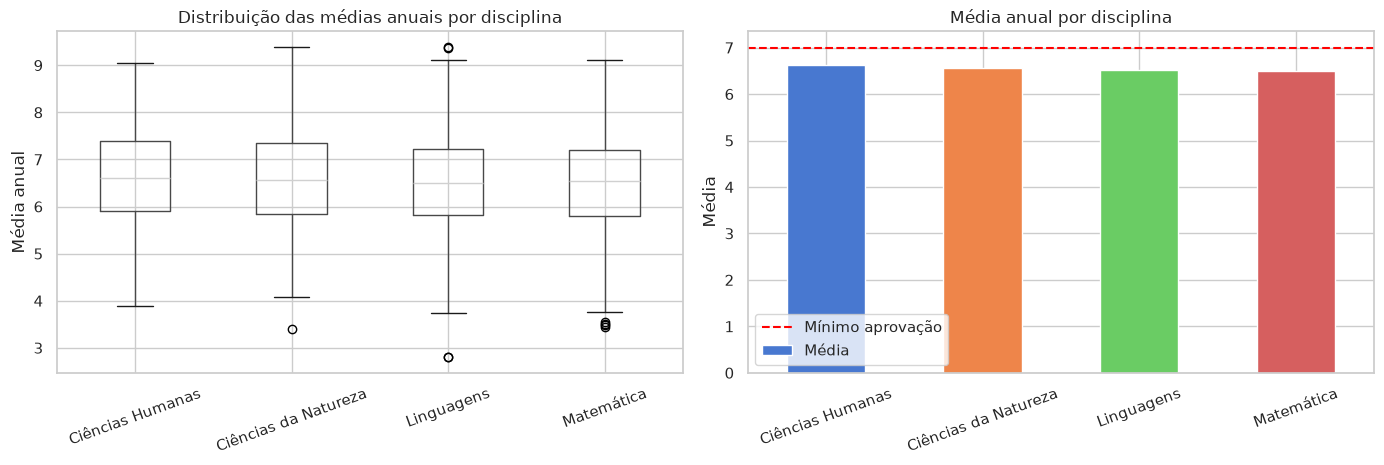

In [58]:
# ── 4.1 Visão geral — médias por disciplina ───────────────
media_por_disc = (
    consolidado.groupby('disciplina')['media_anual']
    .agg(['mean','std','min','max'])
    .round(2)
    .rename(columns={'mean':'Média','std':'Desvio Padrão','min':'Mínimo','max':'Máximo'})
)
print('=== Médias anuais por disciplina ===')
display(media_por_disc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
consolidado.boxplot(column='media_anual', by='disciplina', ax=axes[0])
axes[0].set_title('Distribuição das médias anuais por disciplina')
axes[0].set_xlabel('')
axes[0].set_ylabel('Média anual')
axes[0].tick_params(axis='x', rotation=20)
plt.suptitle('')

# Média por disciplina
media_por_disc['Média'].plot(kind='bar', ax=axes[1], color=sns.color_palette('muted', 4))
axes[1].set_title('Média anual por disciplina')
axes[1].set_ylabel('Média')
axes[1].set_xlabel('')
axes[1].axhline(LIMITE_NOTA_APROVACAO, color='red', linestyle='--', label='Mínimo aprovação')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

=== Média por série e disciplina ===


disciplina,Ciências Humanas,Ciências da Natureza,Linguagens,Matemática
serie,,,,
1º Ano,6.59,6.49,6.51,6.52
2º Ano,6.62,6.54,6.53,6.57
3º Ano,6.65,6.69,6.48,6.43


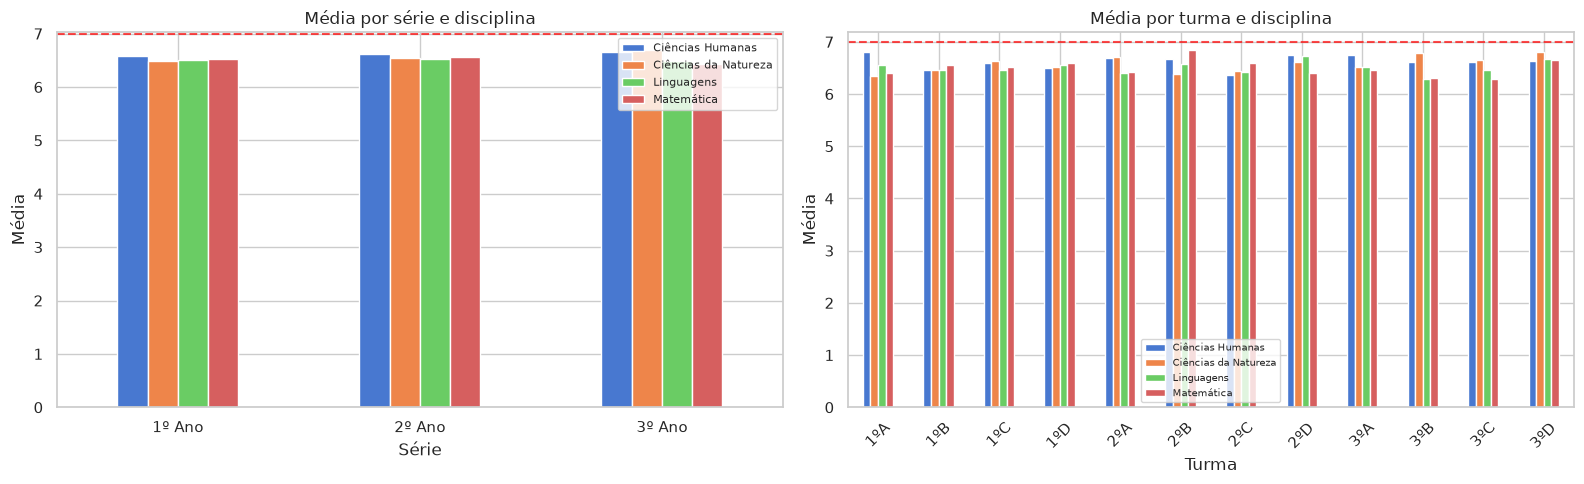

In [59]:
# ── 4.2 Desempenho por série e turma ──────────────────────
media_serie = (
    consolidado.groupby(['serie','disciplina'])['media_anual']
    .mean().round(2).unstack()
)
print('=== Média por série e disciplina ===')
display(media_serie)

media_turma = (
    consolidado.groupby(['turma','disciplina'])['media_anual']
    .mean().round(2).unstack()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
media_serie.plot(kind='bar', ax=axes[0])
axes[0].set_title('Média por série e disciplina')
axes[0].set_xlabel('Série')
axes[0].set_ylabel('Média')
axes[0].axhline(LIMITE_NOTA_APROVACAO, color='red', linestyle='--', alpha=0.7)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(fontsize=8)

media_turma.plot(kind='bar', ax=axes[1])
axes[1].set_title('Média por turma e disciplina')
axes[1].set_xlabel('Turma')
axes[1].set_ylabel('Média')
axes[1].axhline(LIMITE_NOTA_APROVACAO, color='red', linestyle='--', alpha=0.7)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

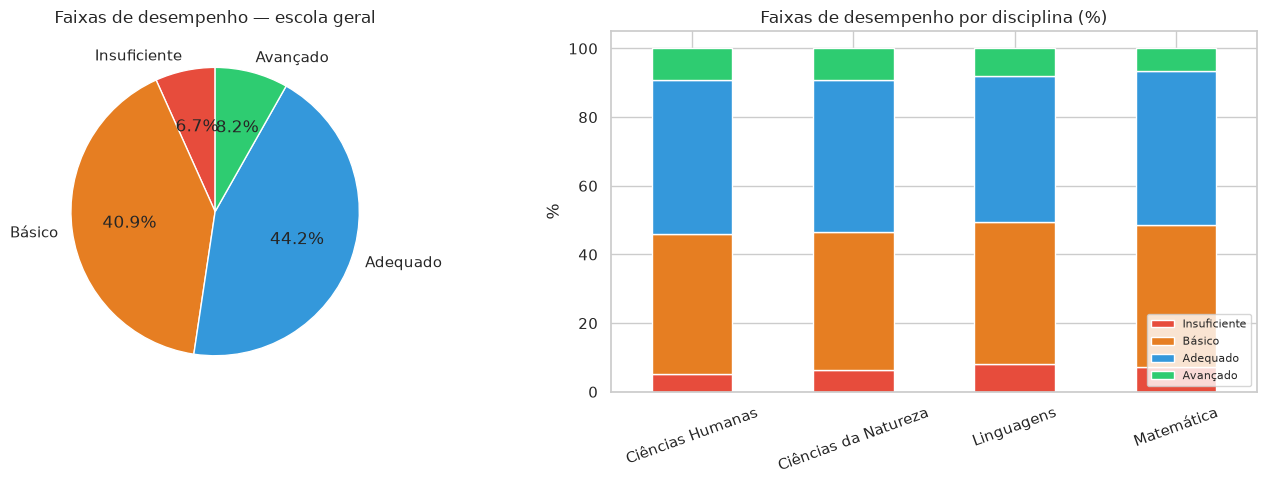

In [60]:
# ── 4.3 Faixas de desempenho (gráfico de pizza) ───────────
faixas_ordem = ['Insuficiente', 'Básico', 'Adequado', 'Avançado']
cores_faixas = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Geral
faixas_geral = consolidado['faixa_desempenho'].value_counts().reindex(faixas_ordem).fillna(0)
axes[0].pie(faixas_geral, labels=faixas_geral.index, autopct='%1.1f%%',
            colors=cores_faixas, startangle=90)
axes[0].set_title('Faixas de desempenho — escola geral')

# Por disciplina (stacked bar)
faixas_disc = (
    consolidado.groupby(['disciplina','faixa_desempenho'])
    .size().unstack().reindex(columns=faixas_ordem).fillna(0)
)
faixas_disc_pct = faixas_disc.div(faixas_disc.sum(axis=1), axis=0) * 100
faixas_disc_pct.plot(kind='bar', stacked=True, ax=axes[1],
                     color=cores_faixas)
axes[1].set_title('Faixas de desempenho por disciplina (%)')
axes[1].set_ylabel('%')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

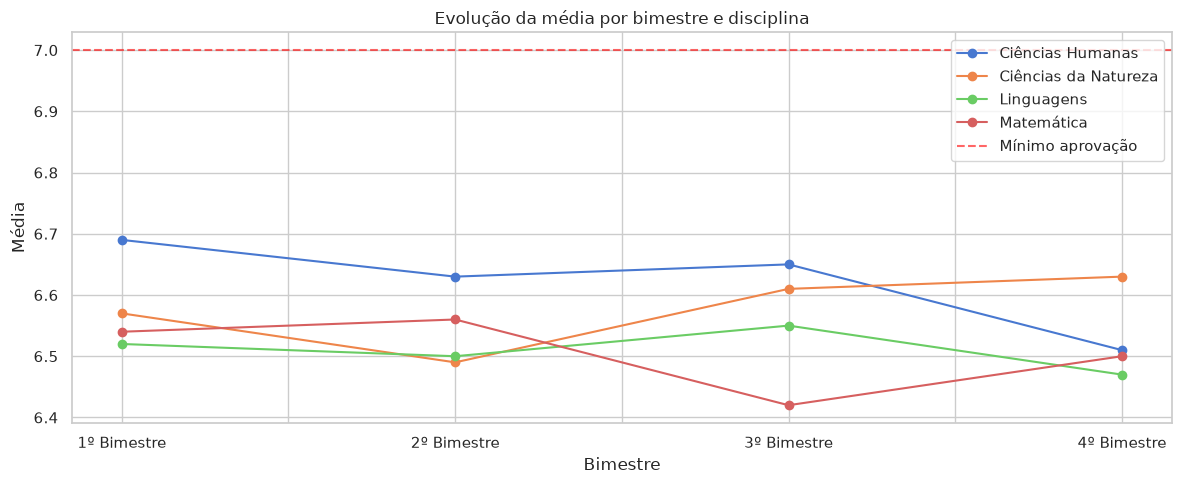

disciplina   Ciências Humanas  Ciências da Natureza  Linguagens  Matemática
1º Bimestre              6.69                  6.57        6.52        6.54
2º Bimestre              6.63                  6.49        6.50        6.56
3º Bimestre              6.65                  6.61        6.55        6.42
4º Bimestre              6.51                  6.63        6.47        6.50


In [61]:
# ── 4.4 Evolução bimestral ────────────────────────────────
bimestres = ['media_b1','media_b2','media_b3','media_b4']
labels_bim = ['1º Bimestre','2º Bimestre','3º Bimestre','4º Bimestre']

evolucao = (
    consolidado.groupby('disciplina')[bimestres]
    .mean().round(2).T
)
evolucao.index = labels_bim

fig, ax = plt.subplots(figsize=(12, 5))
evolucao.plot(marker='o', ax=ax)
ax.set_title('Evolução da média por bimestre e disciplina')
ax.set_ylabel('Média')
ax.set_xlabel('Bimestre')
ax.axhline(LIMITE_NOTA_APROVACAO, color='red', linestyle='--', alpha=0.6, label='Mínimo aprovação')
ax.legend()
plt.tight_layout()
plt.show()

print(evolucao)

=== Situação por disciplina ===


situacao,Aprovado,Reprovado (nota)
disciplina,,
Ciências Humanas,211,329
Ciências da Natureza,195,345
Linguagens,176,364
Matemática,175,365


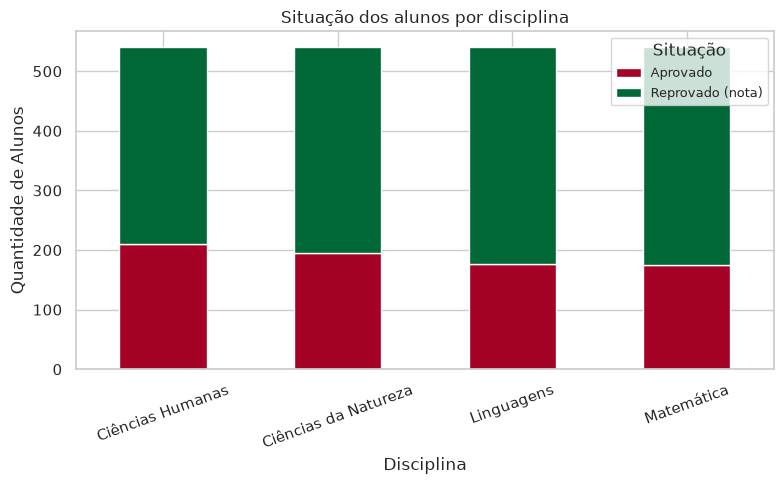

In [62]:
# ── 4.5 Situação acadêmica e desempenho por disciplina ──────────────────
# Agrupa e conta a quantidade de alunos em cada situação por disciplina
situacao_counts = (
    consolidado.groupby(['disciplina', 'situacao'])
    .size().unstack().fillna(0).astype(int)
)

print('=== Situação por disciplina ===')
display(situacao_counts)

# Configuração do gráfico para exibir a distribuição das situações
fig, ax = plt.subplots(figsize=(8, 5))

situacao_counts.plot(
    kind='bar', 
    stacked=True, 
    ax=ax,
    colormap='RdYlGn'
)

ax.set_title('Situação dos alunos por disciplina')
ax.set_xlabel('Disciplina')
ax.set_ylabel('Quantidade de Alunos')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Situação', fontsize=9)

plt.tight_layout()
plt.show()

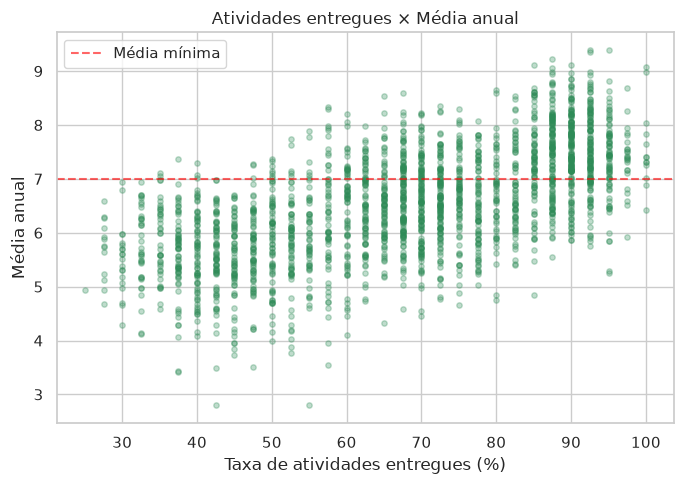

=== Correlações ===
                       media_anual  taxa_atividades_anual
media_anual                   1.00                   0.63
taxa_atividades_anual         0.63                   1.00


In [63]:
# ── 4.6 Correlação nota × atividades ──────────────────────────────────
# Gráfico de dispersão para analisar o impacto das atividades entregues na nota
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    consolidado['taxa_atividades_anual'] * 100,
    consolidado['media_anual'],
    alpha=0.3, 
    s=15, 
    color='seagreen'
)
ax.set_xlabel('Taxa de atividades entregues (%)')
ax.set_ylabel('Média anual')
ax.set_title('Atividades entregues × Média anual')
ax.axhline(LIMITE_NOTA_APROVACAO, color='red', linestyle='--', alpha=0.6, label='Média mínima')
ax.legend()

plt.tight_layout()
plt.show()

# Correlação numérica entre nota e entrega de atividades
corr_cols = ['media_anual', 'taxa_atividades_anual']
print('=== Correlações ===')
print(consolidado[corr_cols].corr().round(3))

## 5. Comparativo Nacional (SAEB + ENEM)

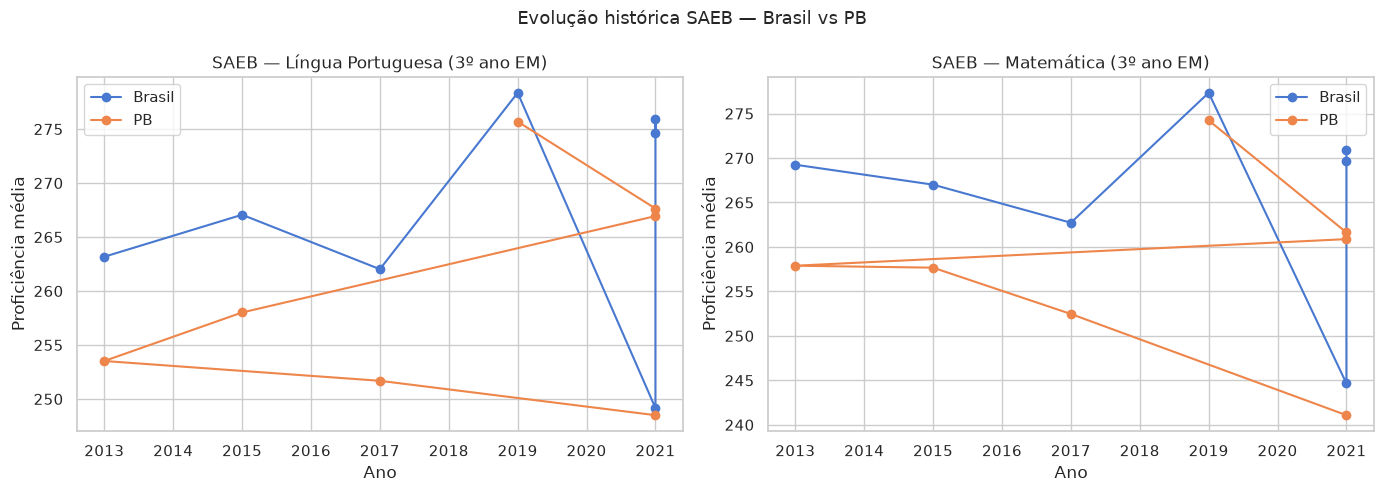

In [64]:
# ── 5.1 SAEB — evolução histórica LP e MT (Brasil vs CE) ──
# Filtrar rede total para comparação justa
filtro_rede = 'total - federal, estadual, municipal e privada'

saeb_br_total = saeb_brasil[
    saeb_brasil['rede'] == filtro_rede
][['ano','disciplina','media']].copy()
saeb_br_total['origem'] = 'Brasil'

saeb_ce_total = saeb_uf[
    saeb_uf['rede'] == filtro_rede
][['ano','disciplina','media']].copy()
saeb_ce_total['origem'] = UF_ESCOLA

saeb_comp = pd.concat([saeb_br_total, saeb_ce_total])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, disc, titulo in zip(
    axes,
    ['LP', 'MT'],
    ['Língua Portuguesa', 'Matemática']
):
    subset = saeb_comp[saeb_comp['disciplina'] == disc]
    for origem, grp in subset.groupby('origem'):
        ax.plot(grp['ano'], grp['media'], marker='o', label=origem)
    ax.set_title(f'SAEB — {titulo} (3º ano EM)')
    ax.set_xlabel('Ano')
    ax.set_ylabel('Proficiência média')
    ax.legend()

plt.suptitle(f'Evolução histórica SAEB — Brasil vs {UF_ESCOLA}', fontsize=13)
plt.tight_layout()
plt.show()

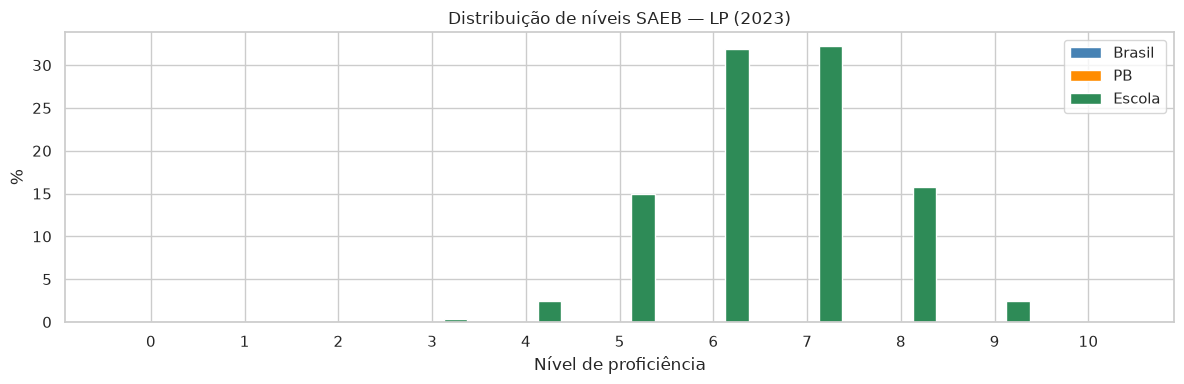

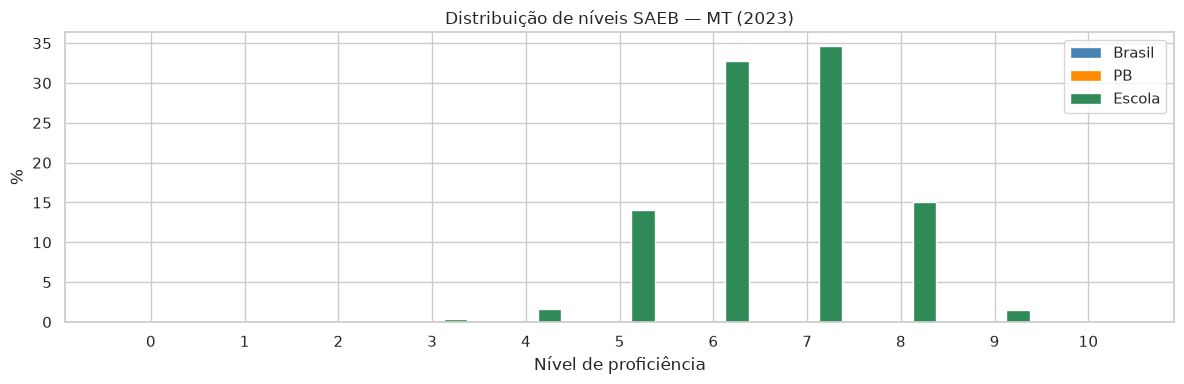

In [65]:
# ── 5.2 SAEB — distribuição de níveis (ano mais recente) ──
nivel_cols = [f'nivel_{i}' for i in range(11)]

saeb_ref_br = saeb_brasil[
    (saeb_brasil['ano'] == ANO_SAEB_REF) &
    (saeb_brasil['rede'] == filtro_rede)
][['disciplina'] + nivel_cols].set_index('disciplina')

saeb_ref_ce = saeb_uf[
    (saeb_uf['ano'] == ANO_SAEB_REF) &
    (saeb_uf['rede'] == filtro_rede)
][['disciplina'] + nivel_cols].set_index('disciplina')

# Distribuição de níveis da escola (estimada)
escola_niveis = (
    consolidado[
        consolidado['disciplina_key'].isin(['matematica','linguagens'])
    ].groupby('disciplina_key')['nivel_saeb_est']
    .value_counts(normalize=True).mul(100).unstack().fillna(0)
)
escola_niveis.index = ['MT' if 'mat' in i else 'LP' for i in escola_niveis.index]
escola_niveis.columns = [f'nivel_{c}' for c in escola_niveis.columns]

for disc in ['LP', 'MT']:
    fig, ax = plt.subplots(figsize=(12, 4))
    x = np.arange(11)
    w = 0.25

    def safe_get(df, disc, col):
        try: return float(df.loc[disc, col])
        except: return 0.0

    br_vals  = [safe_get(saeb_ref_br, disc, c) for c in nivel_cols]
    ce_vals  = [safe_get(saeb_ref_ce, disc, c) for c in nivel_cols]
    esc_vals = [safe_get(escola_niveis, disc, c) for c in nivel_cols]

    ax.bar(x - w, br_vals,  w, label='Brasil', color='steelblue')
    ax.bar(x,     ce_vals,  w, label=UF_ESCOLA,  color='darkorange')
    ax.bar(x + w, esc_vals, w, label='Escola',  color='seagreen')

    ax.set_title(f'Distribuição de níveis SAEB — {disc} ({ANO_SAEB_REF})')
    ax.set_xlabel('Nível de proficiência')
    ax.set_ylabel('%')
    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in range(11)])
    ax.legend()
    plt.tight_layout()
    plt.show()

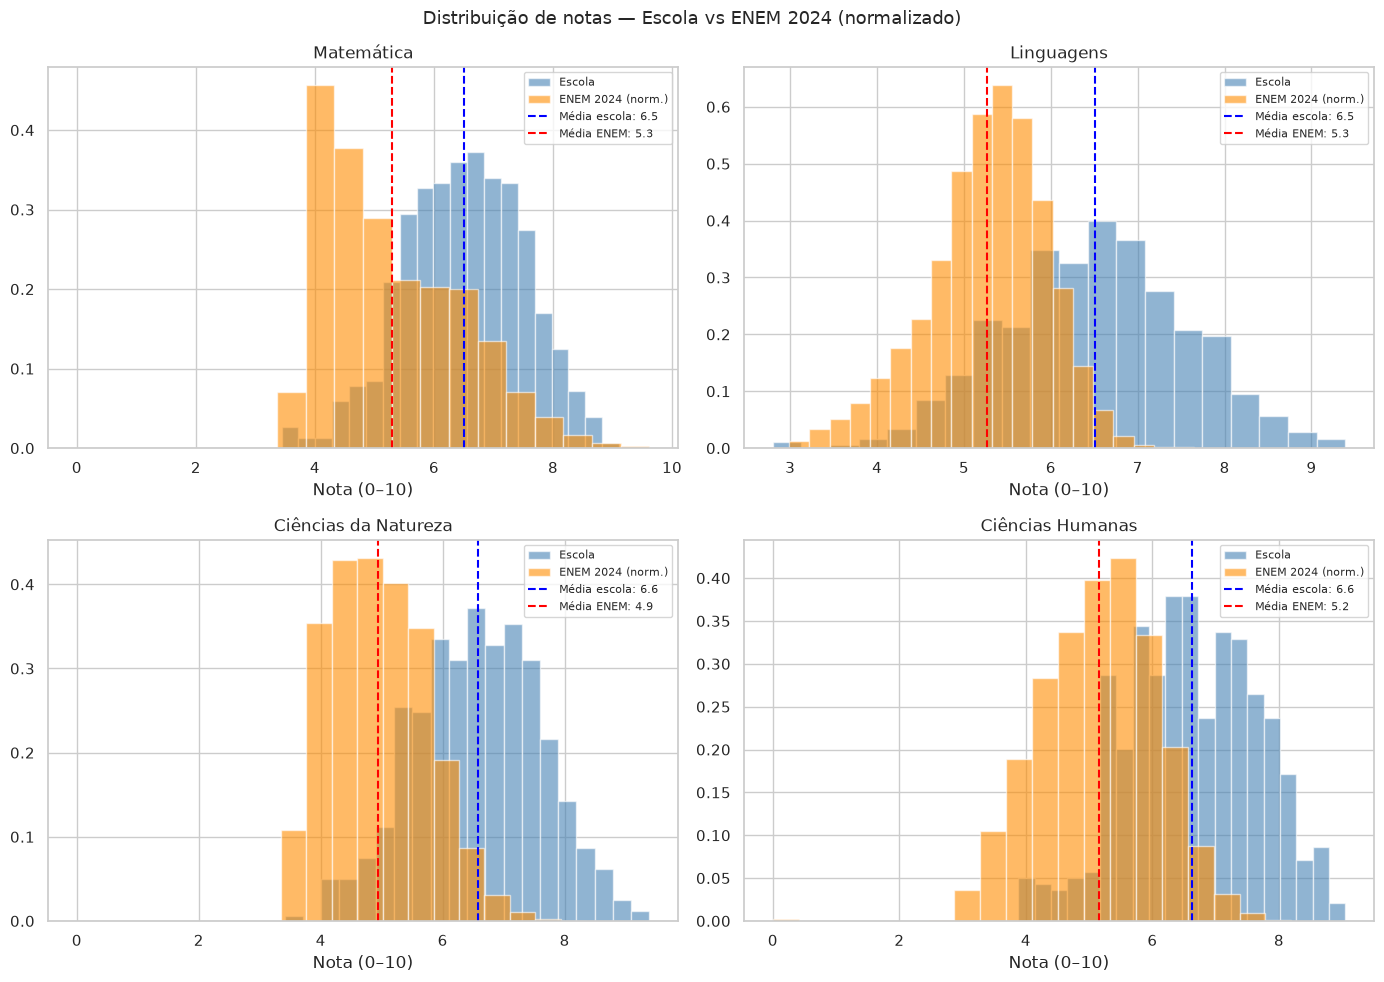

In [66]:
# ── 5.3 ENEM — distribuição das notas vs escola ───────────
mapa_disc_enem = {
    'Matemática':        'matematica',
    'Linguagens':        'linguagens',
    'Ciências da Natureza': 'ciencias_natureza',
    'Ciências Humanas':  'ciencias_humanas'
}

# Escala ENEM ≈ 0–1000; normalizar para 0–10 para comparação visual
enem_norm = enem[list(mapa_disc_enem.keys())].copy()
for col in enem_norm.columns:
    enem_norm[col] = enem_norm[col] / 100  # 0–10

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (disc_label, disc_key) in enumerate(mapa_disc_enem.items()):
    ax = axes[i]
    escola_vals = consolidado[
        consolidado['disciplina_key'] == disc_key
    ]['media_anual']
    enem_vals = enem_norm[disc_label].dropna()

    ax.hist(escola_vals, bins=20, alpha=0.6, label='Escola', color='steelblue', density=True)
    ax.hist(enem_vals,   bins=20, alpha=0.6, label='ENEM 2024 (norm.)',
            color='darkorange', density=True)
    ax.axvline(escola_vals.mean(), color='blue', linestyle='--',
               label=f'Média escola: {escola_vals.mean():.1f}')
    ax.axvline(enem_vals.mean(), color='red', linestyle='--',
               label=f'Média ENEM: {enem_vals.mean():.1f}')
    ax.set_title(disc_label)
    ax.set_xlabel('Nota (0–10)')
    ax.legend(fontsize=8)

plt.suptitle('Distribuição de notas — Escola vs ENEM 2024 (normalizado)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Funções Reutilizáveis para o Streamlit

In [67]:
# Essas funções serão importadas diretamente no app Streamlit

def get_alunos_em_risco(df, min_nota=LIMITE_NOTA_APROVACAO):
    """Retorna alunos em risco de reprovação por nota."""
    return df[
        (df['media_anual'] < min_nota)
    ][['id_aluno', 'nome', 'serie', 'turma', 'disciplina',
       'media_anual', 'situacao']].sort_values('media_anual')


def get_media_por_turma_disciplina(df):
    """Tabela pivot: turma × disciplina com médias."""
    return (
        df.groupby(['turma', 'disciplina'])['media_anual']
        .mean().round(2).unstack()
    )


def get_evolucao_bimestral(df, filtro_serie=None, filtro_turma=None, filtro_disciplina=None):
    """Evolução bimestral com filtros opcionais para o dashboard."""
    tmp = df.copy()
    if filtro_serie:       tmp = tmp[tmp['serie'] == filtro_serie]
    if filtro_turma:       tmp = tmp[tmp['turma'] == filtro_turma]
    if filtro_disciplina:  tmp = tmp[tmp['disciplina'] == filtro_disciplina]

    return (
        tmp.groupby('disciplina')[['media_b1', 'media_b2', 'media_b3', 'media_b4']]
        .mean().round(2)
    )


def get_distribuicao_faixas(df, filtro_serie=None, filtro_turma=None):
    """Distribuição de faixas de desempenho para gráfico de pizza."""
    tmp = df.copy()
    if filtro_serie: tmp = tmp[tmp['serie'] == filtro_serie]
    if filtro_turma: tmp = tmp[tmp['turma'] == filtro_turma]
    return tmp['faixa_desempenho'].value_counts().reindex(
        ['Insuficiente', 'Básico', 'Adequado', 'Avançado']
    ).fillna(0)


def get_saeb_referencia(saeb_br, saeb_uf, disciplina='LP', rede=None):
    """Retorna série histórica SAEB para comparativo."""
    rede = rede or 'total - federal, estadual, municipal e privada'
    br = saeb_br[(saeb_br['disciplina'] == disciplina) & (saeb_br['rede'] == rede)]
    uf = saeb_uf[(saeb_uf['disciplina'] == disciplina) & (saeb_uf['rede'] == rede)]
    return br[['ano', 'media']].rename(columns={'media': 'Brasil'}), \
           uf[['ano', 'media']].rename(columns={'media': UF_ESCOLA})


print('✅ Funções prontas para importar no Streamlit.')
print()
print('Exemplo de uso:')
em_risco = get_alunos_em_risco(consolidado)
print(f'  Alunos em risco: {len(em_risco)} registros')
print(em_risco.head(5).to_string(index=False))

✅ Funções prontas para importar no Streamlit.

Exemplo de uso:
  Alunos em risco: 1403 registros
id_aluno             nome  serie turma           disciplina  media_anual         situacao
20240069   Fernanda Silva 1º Ano   1ºB           Linguagens         2.80 Reprovado (nota)
20240098      Samuel Lima 1º Ano   1ºC           Linguagens         2.81 Reprovado (nota)
20240240 Larissa Oliveira 2º Ano   2ºB Ciências da Natureza         3.41 Reprovado (nota)
20240455    Lucas Martins 3º Ano   3ºC           Matemática         3.44 Reprovado (nota)
20240387      Fábio Souza 3º Ano   3ºA           Matemática         3.49 Reprovado (nota)


## 7. Exportar Dataset Consolidado
Para uso direto no Streamlit sem reprocessar.

In [68]:
# 1. Define o caminho completo da pasta e do arquivo
pasta_output = os.path.join(DADOS_ESCOLA, 'output')
caminho_arquivo = os.path.join(pasta_output, 'consolidado.csv')

# 2. Cria a pasta 'output' automaticamente se ela não existir
os.makedirs(pasta_output, exist_ok=True)

# 3. Salva o arquivo com segurança
consolidado.to_csv(caminho_arquivo, index=False)

print(f'✅ consolidado.csv exportado: {consolidado.shape}')
print()
print('Colunas disponíveis:')
print(list(consolidado.columns))

✅ consolidado.csv exportado: (2160, 48)

Colunas disponíveis:
['id_aluno', 'id_professor', 'aulas_bimestre', 'nota_p1_b1', 'nota_p2_b1', 'ativs_entregues_b1', 'ativs_total_b1', 'faltas_b1', 'nota_p1_b2', 'nota_p2_b2', 'ativs_entregues_b2', 'ativs_total_b2', 'faltas_b2', 'nota_p1_b3', 'nota_p2_b3', 'ativs_entregues_b3', 'ativs_total_b3', 'faltas_b3', 'nota_p1_b4', 'nota_p2_b4', 'ativs_entregues_b4', 'ativs_total_b4', 'faltas_b4', 'disciplina', 'media_b1', 'taxa_atividades_b1', 'media_b2', 'taxa_atividades_b2', 'media_b3', 'taxa_atividades_b3', 'media_b4', 'taxa_atividades_b4', 'media_anual', 'total_faltas', 'frequencia_anual', 'total_ativs_entregues', 'total_ativs', 'taxa_atividades_anual', 'situacao', 'matricula', 'nome', 'turma', 'serie', 'genero', 'data_nascimento', 'disciplina_key', 'faixa_desempenho', 'nivel_saeb_est']
